# Tutorial 08 — LLI/LAM-Bestimmung mit dem Halbzellenfitting

Dieses Tutorial zeigt die Benutzung der LLI/LAM-Pipeline: Aus zwei CheckUp-Messungen
derselben Zelle — einmal frisch (Referenz), einmal gealtert — werden bestimmt:


**Workflow:**

```
Rohdaten einlesen  →  Segmente + Kapazität  →  iOCV extrahieren (Lade-Ast)
      →  Halbzellen-Fit  →  Sichtprüfung  →  Zustands-Dicts  →  lli_lam_covered()
```

.


## Schritt 0 — Imports und Konfiguration

Gebraucht werden drei Bausteine:

- **`pydpeet` (`eet`)** für Einlesen und Aufbereiten,
- **`haf_cell_fitting`** für den Halbzellen-Fit,
- **`pauses`/`ocv_simple`/`capa_covered`** für Ruhespannungs-Anker und die LLI/LAM-Rechnung.

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

import pydpeet as eet

from pydpeet.process.analyze.extract.haf_cell_fitting import (
    get_best_half_cell_fit,     # Halbzellen-Fit inkl. Suche über die Elektroden-Bibliothek
    plot_half_cell_match,       # Standard-Plot zur Sichtprüfung
    dir_anode, dir_cathode,     # Pfade zur mitgelieferten Halbzell-Bibliothek
)
from pydpeet.process.analyze.extract.pauses import extract_pauses
from pydpeet.process.analyze.extract.ocv_simple import pauses_to_ocv_simple
from pydpeet.process.analyze.extract.capa_covered import lli_lam_covered

eet.set_logging_style("ERROR")

# Die beiden Messungen: Referenz (frisch) und gealterter Zustand derselben Zelle
PATH_REF  = "../../../input_data/Input_files_checkup/20231129133302-CheckUp-3-7-AM23NMC00020.xlsx"
PATH_AGED = "../../../input_data/Input_files_checkup/20240216101054-CheckUp-3-8-AM23NMC00020.xlsx"

READER_CONFIG  = "neware_8_0_0_516"     # Zyklisierer-Format (vgl. Tutorial 01)
BATTERY_CONFIG = eet.lgm50lt_nmc_4800   # Zell-Konfiguration (Kapazität, Spannungsgrenzen, …)

## Schritt 1 — Rohdaten einlesen

`eet.read` liest den Export des Zyklisierers in das PyDPEET-Standardformat
(`Test_Time[s]`, `Voltage[V]`, `Current[A]`, …).

In [19]:
df_raw_ref  = eet.read(config=READER_CONFIG, input_path=PATH_REF)
df_raw_aged = eet.read(config=READER_CONFIG, input_path=PATH_AGED)
print(f"Referenz:  {len(df_raw_ref):,} Samples")
print(f"Gealtert:  {len(df_raw_aged):,} Samples")

Referenz:  1,677,735 Samples
Gealtert:  1,675,299 Samples


## Schritt 2 — Segmente und Kapazität ergänzen

Der Fit braucht später eine **SOC-Spalte**. Dafür werden die Messungen segmentiert
(`add_primitive_segments`) und die Kapazität samt SOC ergänzt
(`add_capacity`).

In [3]:
df_seq_ref  = eet.add_primitive_segments(df_raw_ref)
df_seq_aged = eet.add_primitive_segments(df_raw_aged)

df_cap_ref  = eet.add_capacity(df_raw_ref, df_seq_ref, neware_bool=True, config=BATTERY_CONFIG)
df_cap_aged = eet.add_capacity(df_raw_aged, df_seq_aged, neware_bool=True, config=BATTERY_CONFIG)

## Schritt 3 — iOCV extrahieren 

`extract_ocv_iocv` findet die iOCV-Sequenzen im CheckUp. Für den Fit wird der
 (`iOCV_type == "Charge"`) verwendet — das Fitting-Modell ist in Laderichtung
definiert (Anode lithiiert, Kathode delithiiert).

Als Fit-Eingang genügt ein DataFrame mit den Spalten **`SOC`** und **`Voltage[V]`**.

In [4]:
def extract_charge_iocv(df_cap):
    # iOCV-Phasen extrahieren und auf den Lade-Ast filtern
    phases = eet.extract_ocv_iocv(df=df_cap, config=BATTERY_CONFIG, visualize=False)
    df = pd.concat(phases, ignore_index=True)
    df = df.loc[:, ~df.columns.duplicated()]
    return df[df["iOCV_type"] == "Charge"]

df_charge_ref  = extract_charge_iocv(df_cap_ref)
df_charge_aged = extract_charge_iocv(df_cap_aged)

print(f"Referenz:  {len(df_charge_ref)} iOCV-Punkte, SOC {df_charge_ref['SOC'].min():.2f} … {df_charge_ref['SOC'].max():.2f}")
print(f"Gealtert:  {len(df_charge_aged)} iOCV-Punkte, SOC {df_charge_aged['SOC'].min():.2f} … {df_charge_aged['SOC'].max():.2f}")

Referenz:  121 iOCV-Punkte, SOC 0.00 … 1.00
Gealtert:  119 iOCV-Punkte, SOC 0.00 … 0.97


## Schritt 4 — Halbzellen-Fit

`get_best_half_cell_fit` probiert **jede Anoden-/Kathoden-Kombination** der mitgelieferten
Halbzell-Bibliothek durch und gibt den besten Fit zurück (eine DataFrame-Zeile mit
Elektrodenpaar, Stöchiometriefenster `Sol_*` und Fit-Güte `RMSE[mV]`).

Nützliche Parameter:

| Parameter | Zweck |
|-----------|-------|
| `full_cell_name` | Beschriftung des Ergebnisses (taucht in der Spalte `FullCell` auf) |
| `anodes_dir`, `cathodes_dir` | eigene Halbzellkurven verwenden (CSV mit Spalten `Lithiation`, `OCV`) |
| `full_x_col`, `full_y_col` | abweichende Spaltennamen des Eingangs-DataFrames |




In [5]:
best_fit_ref  = get_best_half_cell_fit(df_charge_ref, full_cell_name="CheckUp_Referenz")
best_fit_aged = get_best_half_cell_fit(df_charge_aged, full_cell_name="CheckUp_gealtert")

fit_overview = pd.concat([best_fit_ref, best_fit_aged], ignore_index=True)
fit_overview.index = ["Referenz", "gealtert"]
fit_overview[["FullCell", "Anode", "Cathode", "RMSE[mV]",
              "Sol_Anode_Min", "Sol_Anode_Max", "Sol_Cathode_Min", "Sol_Cathode_Max"]].round(4)

,FullCell,Anode,Cathode,RMSE[mV],Sol_Anode_Min,Sol_Anode_Max,Sol_Cathode_Min,Sol_Cathode_Max
Referenz,CheckUp_Referenz,"Graphite, Ecker2015.csv","NMC811, Chen2020.csv",13.3687,0.0015,1.0,0.2669,0.8454
gealtert,CheckUp_gealtert,"Graphite, Ecker2015.csv","NMC811, Chen2020.csv",13.5095,0.0023,1.0,0.2610,0.8475


Beide Zustände sollten auf **dasselbe Elektrodenpaar** fitten.


## Schritt 5 — Plotting

`plot_half_cell_match` zeichnet Messung, simulierte Vollzelle und die beiden zurückgerechneten
Elektrodenkurven (und speichert den Plot als PNG im Arbeitsverzeichnis). Worauf achten:

- Die **rote Simulation** sollte die **blaue Messung** praktisch decken.
- Die Elektrodenkurven sollten physikalisch plausibel liegen (Anode unten, Kathode oben).

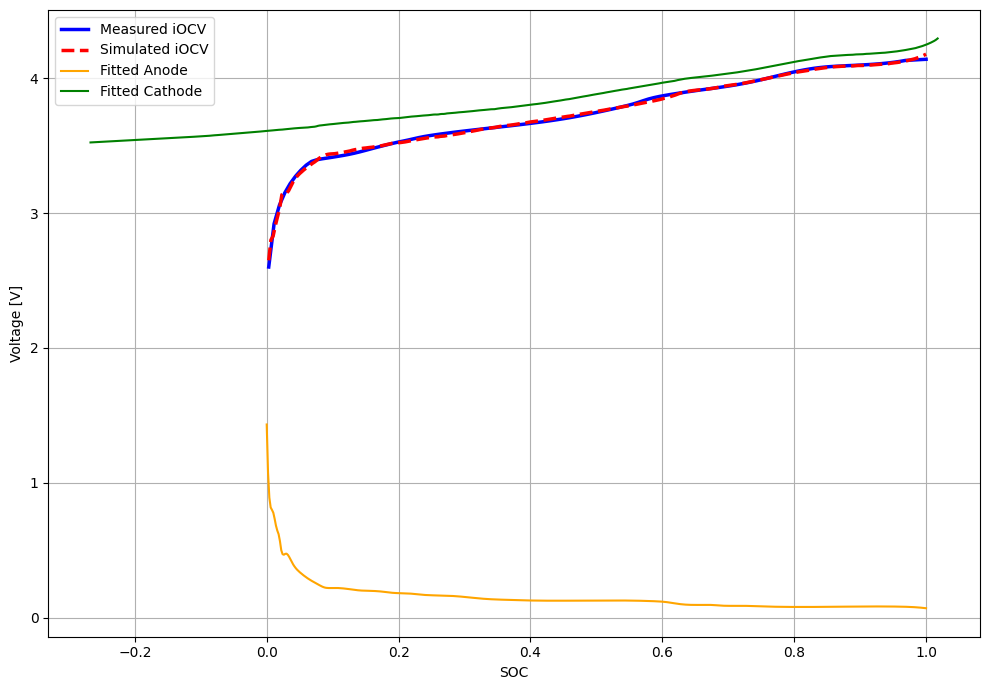

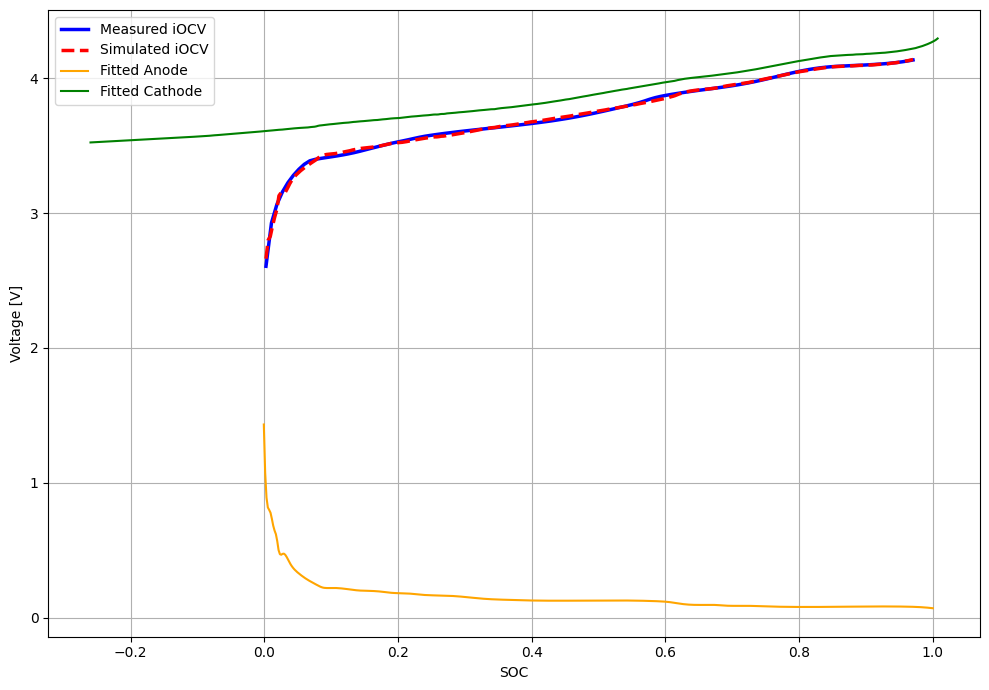

In [6]:
for label, best_fit, df_charge in [("Referenz", best_fit_ref, df_charge_ref),
                                    ("gealtert", best_fit_aged, df_charge_aged)]:
    plot_half_cell_match(
        full_df        = df_charge,
        anode_df       = pd.read_csv(f"{dir_anode}/{best_fit['Anode'].iloc[0]}"),
        cathode_df     = pd.read_csv(f"{dir_cathode}/{best_fit['Cathode'].iloc[0]}"),
        solution_array = best_fit["Solution_Array"].iloc[0],
        filename       = f"Tutorial08_LLI_LAM_Fit_{label}.png",
    )

Zwischenschritt, extrahieren der Pausen und OCV Punkte zur Kapazitätsbestimmung




In [7]:
def build_state(df_cap, df_charge, best_fit, min_pause_duration_s=60):
    # Zeitfenster der iOCV-Ladesequenz aus der Gesamtmessung schneiden
    t0, t1 = df_charge["Test_Time[s]"].min(), df_charge["Test_Time[s]"].max()
    seg = df_cap[(df_cap["Test_Time[s]"] >= t0) & (df_cap["Test_Time[s]"] <= t1)]
    anchors = pauses_to_ocv_simple(extract_pauses(seg, min_pause_duration_s=min_pause_duration_s))
    return {
        "df":         seg,
        "anchors":    anchors,
        "fit_result": best_fit,
        "anode_df":   pd.read_csv(f"{dir_anode}/{best_fit['Anode'].iloc[0]}"),
        "cathode_df": pd.read_csv(f"{dir_cathode}/{best_fit['Cathode'].iloc[0]}"),
    }

state_ref  = build_state(df_cap_ref, df_charge_ref, best_fit_ref)
state_aged = build_state(df_cap_aged, df_charge_aged, best_fit_aged)
print(f"Anker Referenz: {len(state_ref['anchors'])}   Anker gealtert: {len(state_aged['anchors'])}")

Anker Referenz: 120   Anker gealtert: 118


## Schritt 7 — LLI/LAM berechnen

Ein Aufruf erledigt den Rest: `lli_lam_covered(referenz, gealtert)` bestimmt für beide Zustände
die Kapazität über den **gemeinsam abgedeckten SOC-Bereich** und daraus die Degradationsgrößen.

Die wichtigsten Ausgabespalten:

| Spalte | Bedeutung |
|--------|-----------|
| `Full_Cell_Cap_ref_mAh`, `Full_Cell_Cap_mAh` | gemessene Kapazitäten (Referenz / gealtert) |
| `SOH_pct` | Kapazität gealtert / Referenz × 100 |
| `LLI_mAh`, `LLI_pct` | Lithium-Inventar-Verlust (Prozent **relativ zum Inventar**, nicht zur Kapazität) |
| `LAM_Anode_pct`, `LAM_Cathode_pct` | Aktivmaterial-Verlust je Elektrode |
| `SOC_window_lo`, `SOC_window_hi` | verwendetes gemeinsames SOC-Fenster |



In [8]:
lli_lam_result = lli_lam_covered(state_ref, state_aged)

print(f"Gemeinsames SOC-Fenster: {lli_lam_result['SOC_window_lo'].iloc[0]:.3f} … "
      f"{lli_lam_result['SOC_window_hi'].iloc[0]:.3f}")
lli_lam_result[["Full_Cell_Cap_ref_mAh", "Full_Cell_Cap_mAh", "SOH_pct",
                "LLI_mAh", "LLI_pct",
                "LAM_Anode_mAh", "LAM_Anode_pct",
                "LAM_Cathode_mAh", "LAM_Cathode_pct"]].round(2).T

Gemeinsames SOC-Fenster: 0.014 … 0.967


,0
Full_Cell_Cap_ref_mAh,4243.03
Full_Cell_Cap_mAh,4239.80
SOH_pct,99.92
LLI_mAh,70.56
LLI_pct,1.14
LAM_Anode_mAh,-0.29
LAM_Anode_pct,-0.01
LAM_Cathode_mAh,105.11
LAM_Cathode_pct,1.43
